Loading Google Muril Tokenizer...
✅ Successfully loaded 33 sentences from Gora_Dataset - Sheet1.csv
Running audit... (This may take 10 seconds)

🔬 FINAL RESEARCH RESULTS
HINDI Efficiency Score:   1.194 (Baseline)
GORMATI Efficiency Score: 1.693 (High Cost)
⚠️ INEFFICIENCY GAP:      41.83%

✅ Graph saved as 'fertility_distribution.png'


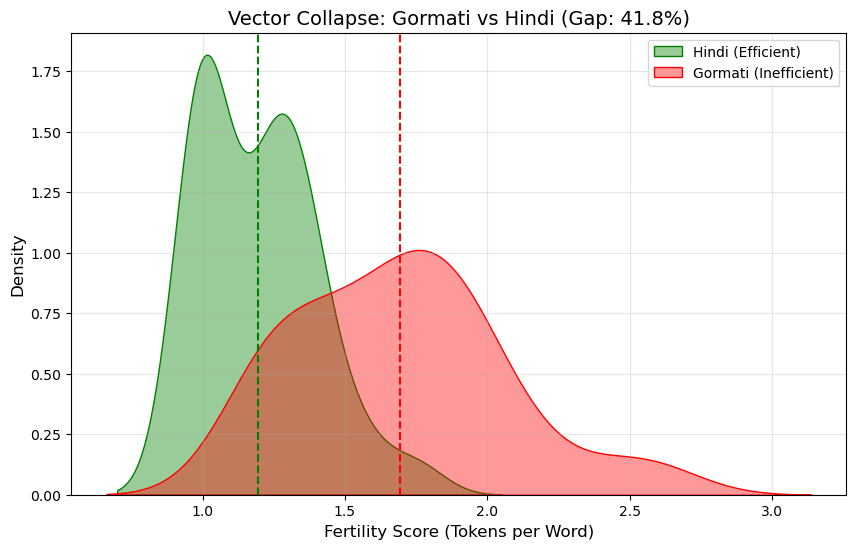

✅ Heatmap saved as 'token_heatmap.png'


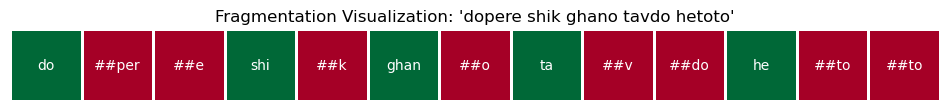

In [1]:
# ==========================================
# PROJECT GORA: FINAL TOKENIZATION AUDIT
# ==========================================

# 1. INSTALL DEPENDENCIES (If needed)
# !pip install transformers seaborn matplotlib -q  # Uncomment if running in Colab

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import numpy as np

# 2. SETUP THE BRAIN (Google Muril)
print("Loading Google Muril Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")

# 3. LOAD YOUR DATA
filename = "Gora_Dataset - Sheet1.csv"
try:
    df = pd.read_csv(filename)
    print(f"✅ Successfully loaded {len(df)} sentences from {filename}")
except FileNotFoundError:
    print(f"❌ ERROR: Could not find '{filename}'. Please upload the CSV file first!")
    df = pd.DataFrame() # Empty to prevent crash

# 4. RUN THE EXPERIMENT (The Loop)
if not df.empty:
    results = []
    print("Running audit... (This may take 10 seconds)")

    for index, row in df.iterrows():
        # Gormati (Target)
        g_text = str(row['gormati'])
        g_tokens = tokenizer.tokenize(g_text)
        g_len = len(g_tokens)
        g_words = len(g_text.split())
        g_score = g_len / g_words if g_words > 0 else 0

        # Hindi (Baseline)
        h_text = str(row['hindi'])
        h_tokens = tokenizer.tokenize(h_text)
        h_len = len(h_tokens)
        h_words = len(h_text.split())
        h_score = h_len / h_words if h_words > 0 else 0

        results.append({
            "Gormati": g_text,
            "G_Score": g_score,
            "H_Score": h_score,
            "Tag": row.get('tag', 'General')
        })

    # Convert to Dataframe
    res_df = pd.DataFrame(results)

    # 5. CALCULATE THE "MAGIC NUMBERS"
    avg_g = res_df['G_Score'].mean()
    avg_h = res_df['H_Score'].mean()
    gap = ((avg_g / avg_h) - 1) * 100

    print("\n" + "="*50)
    print("🔬 FINAL RESEARCH RESULTS")
    print("="*50)
    print(f"HINDI Efficiency Score:   {round(avg_h, 3)} (Baseline)")
    print(f"GORMATI Efficiency Score: {round(avg_g, 3)} (High Cost)")
    print(f"⚠️ INEFFICIENCY GAP:      {round(gap, 2)}%")
    print("="*50)

    # 6. GENERATE THE "TWO MOUNTAINS" GRAPH
    plt.figure(figsize=(10, 6))
    sns.kdeplot(res_df['H_Score'], fill=True, color='green', label='Hindi (Efficient)', alpha=0.4)
    sns.kdeplot(res_df['G_Score'], fill=True, color='red', label='Gormati (Inefficient)', alpha=0.4)
    
    plt.title(f"Vector Collapse: Gormati vs Hindi (Gap: {round(gap, 1)}%)", fontsize=14)
    plt.xlabel("Fertility Score (Tokens per Word)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.axvline(avg_h, color='green', linestyle='--')
    plt.axvline(avg_g, color='red', linestyle='--')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the graph for your GitHub
    plt.savefig("fertility_distribution.png", dpi=300)
    print("\n✅ Graph saved as 'fertility_distribution.png'")
    plt.show()

    # 7. GENERATE THE HEATMAP (Visual Proof)
    # Let's visualize the "Summer" (Undale) sentence failure
    # We look for the worst sentence to visualize
    worst_idx = res_df['G_Score'].idxmax()
    target_sentence = res_df.loc[worst_idx, 'Gormati']
    
    tokens = tokenizer.tokenize(target_sentence)
    # Color map: 1 (Green) for whole words, 0 (Red) for ##fragments
    scores = [1 if "##" not in t else 0 for t in tokens]

    plt.figure(figsize=(12, 2))
    sns.heatmap([scores], annot=[tokens], fmt="", cmap="RdYlGn", cbar=False, 
                xticklabels=False, yticklabels=False, square=True, linewidths=1, linecolor='white')
    plt.title(f"Fragmentation Visualization: '{target_sentence}'")
    plt.savefig("token_heatmap.png", dpi=300)
    print("✅ Heatmap saved as 'token_heatmap.png'")
    plt.show()

else:
    print("Skipping analysis due to missing file.")